 ================================
 
 VoltRide demand forecasting (zone-wise) with SARIMA
 ----------------------------------------------------------
 Goal:
   Predict daily ride demand (ride_requests) for each (City, Pickup_Zone),
   and forecast the next 7 days zone-wise.

 Key points:
   - Target is built as: count of Ride_ID per (City, Pickup_Zone, date)
   - Model: univariate SARIMA per zone
   - Holdout test: last 14 days per zone
   - Forecast horizon: next 7 days per zone
   - Outputs: sarima_params, metrics_table, zonewise_wide_next7
==========================================================


In [23]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


 1) Settings

In [24]:
FILE_PATH = "DecodeX_VoltRide_Dataset.xlsx"
SHEET_NAME = "Ride_Level_Data"

TARGET = "ride_requests"

TEST_DAYS = 14          # last N days per zone used as holdout test
FORECAST_DAYS = 7       # next N days to predict

# SARIMA configuration (tune if needed)
SARIMA_ORDER = (1, 1, 1)
SARIMA_SEASONAL_ORDER = (1, 1, 1, 7)  # weekly seasonality
ENFORCE_STATIONARITY = False
ENFORCE_INVERTIBILITY = False

# plotting (just smoothing for nicer charts)
PLOT_SMOOTH = 7


2) Utility helpers

In [25]:
def safe_mape(y_true, y_pred):
    """MAPE that won't blow up when y_true is 0."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.where(np.abs(y_true) < 1e-9, np.nan, np.abs(y_true))
    return np.nanmean(np.abs((y_true - y_pred) / denom)) * 100


3) Load the raw data

In [26]:
df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)

needed = ["Date", "Ride_ID", "City", "Pickup_Zone"]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
if df["Date"].isna().any():
    raise ValueError("Some Date values couldn't be parsed. Please check the 'Date' column.")

df["date"] = df["Date"].dt.floor("D")


4) Aggregate to daily zone demand

In [27]:
group_keys = ["City", "Pickup_Zone", "date"]
agg = {TARGET: ("Ride_ID", "count")}  # <-- target creation

daily = df.groupby(group_keys).agg(**agg).reset_index()
daily = daily.sort_values(["City", "Pickup_Zone", "date"]).reset_index(drop=True)


5) Holdout split (last TEST_DAYS per zone)

In [28]:
daily["rank_from_end"] = daily.groupby(["City", "Pickup_Zone"])["date"].rank(method="first", ascending=False)
daily["is_test"] = daily["rank_from_end"] <= TEST_DAYS

train_base = daily[~daily["is_test"]].copy().reset_index(drop=True)
test_base  = daily[daily["is_test"]].copy().reset_index(drop=True)

test_keys = set(zip(test_base["City"], test_base["Pickup_Zone"], test_base["date"]))


6) SARIMA setup

In [29]:
def fit_sarima(series: pd.Series):
    model = SARIMAX(
        series,
        order=SARIMA_ORDER,
        seasonal_order=SARIMA_SEASONAL_ORDER,
        enforce_stationarity=ENFORCE_STATIONARITY,
        enforce_invertibility=ENFORCE_INVERTIBILITY,
    )
    return model.fit(disp=False)

zones = daily[["City", "Pickup_Zone"]].drop_duplicates().reset_index(drop=True)

seasonal_period = SARIMA_SEASONAL_ORDER[3] if SARIMA_SEASONAL_ORDER else 0
min_history = max(TEST_DAYS + 1, seasonal_period * 2 if seasonal_period else TEST_DAYS + 1)

sarima_params = {
    "order": SARIMA_ORDER,
    "seasonal_order": SARIMA_SEASONAL_ORDER,
    "enforce_stationarity": ENFORCE_STATIONARITY,
    "enforce_invertibility": ENFORCE_INVERTIBILITY,
}


7) Fit per zone + holdout predictions

In [30]:
holdout_rows = []
future_rows = []
failed_zones = []

for _, z in zones.iterrows():
    city = z["City"]
    zone = z["Pickup_Zone"]

    zone_df = daily[(daily["City"] == city) & (daily["Pickup_Zone"] == zone)].copy()
    zone_df = zone_df.sort_values("date").reset_index(drop=True)

    if len(zone_df) < min_history:
        continue

    train = zone_df.iloc[:-TEST_DAYS]
    test = zone_df.iloc[-TEST_DAYS:]

    try:
        res = fit_sarima(train[TARGET].astype(float))
        pred_test = res.forecast(steps=len(test))
        pred_test = np.clip(np.asarray(pred_test, dtype=float), 0, None)

        for d, y_t, y_p in zip(test["date"], test[TARGET].astype(float).values, pred_test):
            holdout_rows.append({
                "City": city,
                "Pickup_Zone": zone,
                "date": d,
                "y_true": float(y_t),
                "y_pred": float(y_p),
            })

        res_full = fit_sarima(zone_df[TARGET].astype(float))
        future_dates = pd.date_range(zone_df["date"].max() + pd.Timedelta(days=1), periods=FORECAST_DAYS, freq="D")
        pred_future = res_full.forecast(steps=FORECAST_DAYS)
        pred_future = np.clip(np.asarray(pred_future, dtype=float), 0, None)

        for d, y_p in zip(future_dates, pred_future):
            future_rows.append({
                "City": city,
                "Pickup_Zone": zone,
                "date": d,
                "y_pred": float(y_p),
            })
    except Exception as exc:
        failed_zones.append((city, zone, str(exc)))
        continue

holdout_pred = pd.DataFrame(holdout_rows)
next_week_pred = pd.DataFrame(future_rows).sort_values(["City", "Pickup_Zone", "date"]).reset_index(drop=True)


8) Holdout evaluation (real test)

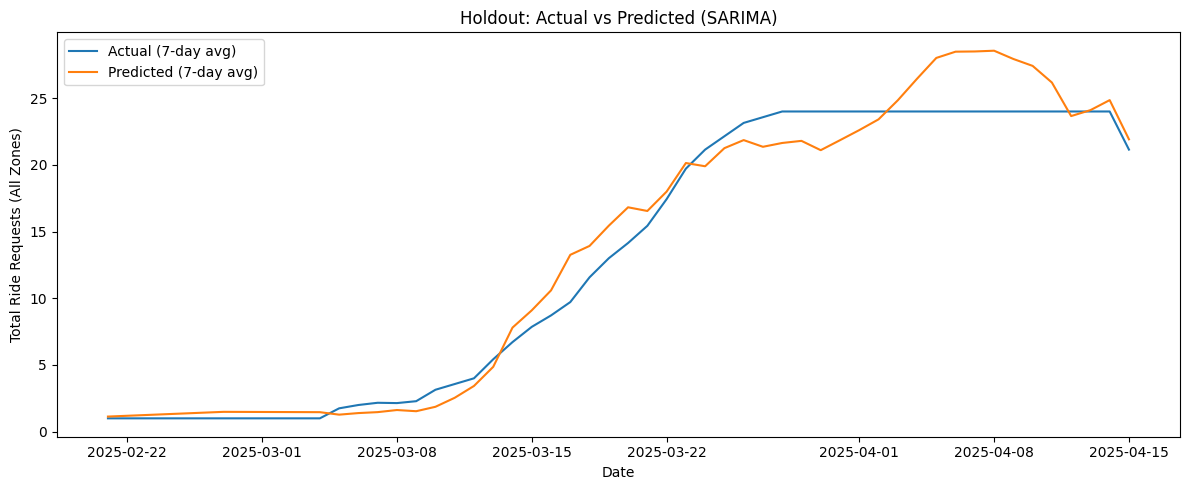

In [31]:
if holdout_pred.empty:
    raise ValueError("No holdout predictions were generated. Try relaxing SARIMA settings or check data coverage.")

y_pred = holdout_pred["y_pred"].values
y_test = holdout_pred["y_true"].values

mae_val = mean_absolute_error(y_test, y_pred)
rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
mape_val = safe_mape(y_test, y_pred)
r2_val = r2_score(y_test, y_pred)

# "accuracy-like" (not standard regression, but you asked for accuracy)
acc_like = 1 - (mae_val / (np.mean(y_test) + 1e-9))

metrics_table = pd.DataFrame([{
    "SARIMA order": str(SARIMA_ORDER),
    "SARIMA seasonal": str(SARIMA_SEASONAL_ORDER),
    "MAE (holdout)": float(mae_val),
    "RMSE (holdout)": float(rmse_val),
    "MAPE % (holdout)": float(mape_val),
    "R2 (holdout)": float(r2_val),
    "Accuracy_like (1 - MAE/mean_y)": float(acc_like),
    "zones_used": int(holdout_pred[["City", "Pickup_Zone"]].drop_duplicates().shape[0]),
}])

# nice holdout plot (smoothed for readability)
hold_plot = holdout_pred.groupby("date", as_index=False).agg(y_true=("y_true", "sum"), y_pred=("y_pred", "sum"))
hold_plot["y_true_smooth"] = hold_plot["y_true"].rolling(PLOT_SMOOTH, min_periods=1).mean()
hold_plot["y_pred_smooth"] = hold_plot["y_pred"].rolling(PLOT_SMOOTH, min_periods=1).mean()

plt.figure(figsize=(12, 5))
plt.plot(hold_plot["date"], hold_plot["y_true_smooth"], label=f"Actual ({PLOT_SMOOTH}-day avg)")
plt.plot(hold_plot["date"], hold_plot["y_pred_smooth"], label=f"Predicted ({PLOT_SMOOTH}-day avg)")
plt.title("Holdout: Actual vs Predicted (SARIMA)")
plt.xlabel("Date")
plt.ylabel("Total Ride Requests (All Zones)")
plt.legend()
plt.tight_layout()
plt.show()


9) Forecast next 7 days (zone-wise)

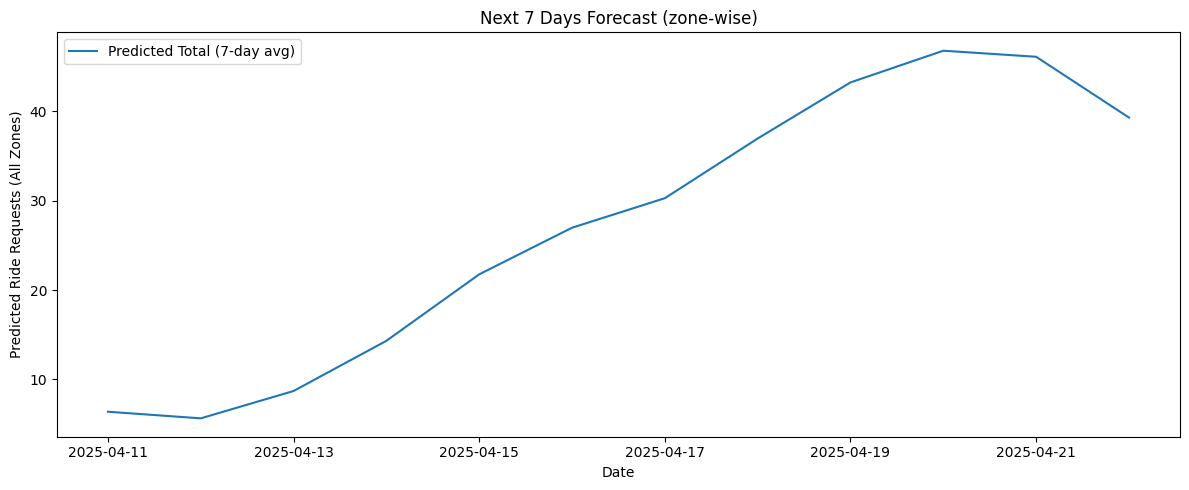

In [32]:
if next_week_pred.empty:
    raise ValueError("No forecasts were generated. Check SARIMA settings or data coverage.")

# Make a wide table (one row per zone, dates as columns)
zonewise_wide_next7 = next_week_pred.pivot_table(
    index=["City", "Pickup_Zone"],
    columns="date",
    values="y_pred",
    aggfunc="mean",
).reset_index()

zonewise_wide_next7.columns = [
    c.strftime("%Y-%m-%d") if isinstance(c, pd.Timestamp) else c
    for c in zonewise_wide_next7.columns
]

# Optional: total forecast plot
next_plot = next_week_pred.groupby("date", as_index=False).agg(total_pred=("y_pred", "sum"))
next_plot["total_pred_smooth"] = next_plot["total_pred"].rolling(PLOT_SMOOTH, min_periods=1).mean()

plt.figure(figsize=(12, 5))
plt.plot(next_plot["date"], next_plot["total_pred_smooth"], label=f"Predicted Total ({PLOT_SMOOTH}-day avg)")
plt.title("Next 7 Days Forecast (zone-wise)")
plt.xlabel("Date")
plt.ylabel("Predicted Ride Requests (All Zones)")
plt.legend()
plt.tight_layout()
plt.show()


10) Final outputs

In [33]:
sarima_params, metrics_table, zonewise_wide_next7

({'order': (1, 1, 1),
  'seasonal_order': (1, 1, 1, 7),
  'enforce_stationarity': False,
  'enforce_invertibility': False},
   SARIMA order SARIMA seasonal  MAE (holdout)  RMSE (holdout)  \
 0    (1, 1, 1)    (1, 1, 1, 7)       0.711004        0.995456   
 
    MAPE % (holdout)  R2 (holdout)  Accuracy_like (1 - MAE/mean_y)  zones_used  
 0         54.895823     -1.656584                        0.467698          40  ,
          City  Pickup_Zone  2025-04-11  2025-04-12  2025-04-13  2025-04-14  \
 0   Bengaluru            1         NaN         NaN         NaN         NaN   
 1   Bengaluru            2         NaN         NaN    1.413414    1.109693   
 2   Bengaluru            3         NaN         NaN         NaN         NaN   
 3   Bengaluru            4         NaN         NaN         NaN    1.364047   
 4   Bengaluru            5         NaN         NaN         NaN         NaN   
 5   Bengaluru            6    3.844576    1.194540    1.094899    1.111501   
 6   Bengaluru            